<a href="https://colab.research.google.com/github/mauracarter-statistics/csc162/blob/main/carter_maura_162_mod3_practice_edge_detection2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**In this activity, you will**:

1. **Detect edges** in an image using OpenCV’s Canny algorithm.

2. **Plot a histogram** of grayscale pixel intensities to visualize the distribution.

3. **Extract and visualize feature** maps from a simple convolutional layer built with TensorFlow/Keras.

We’re using an image from a free online source. Enjoy exploring these core concepts of computer vision!

**Cell 1: Import Libraries and Load the Imag**e

**Description**: This Cell 1 imports all required libraries and downloads an image from a URL. The image is then converted from OpenCV’s default BGR format to RGB for correct display. Finally, the original image is shown using matplotlib.

In [2]:
#python
# Import necessary libraries:
# - cv2: OpenCV for image processing.
# - numpy: For numerical operations and handling image data as arrays.
# - urllib.request: To download the image from a free online source.
# - matplotlib.pyplot: For displaying images and plots.
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt


In [3]:


# Specify the image URL from a free online source (using the classic "Lena" image from the OpenCV repository)
image_url = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg'



In [4]:


# Specify the image URL from a free online source (using the classic "Lena" image from the OpenCV repository)
image_url = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg'




In [5]:

# Download the image from the URL
# - urllib.request.urlopen fetches the image data.
# - bytearray and np.asarray convert the fetched data into a NumPy array.
resp = urllib.request.urlopen(image_url)
image_data = np.asarray(bytearray(resp.read()), dtype="uint8")



In [6]:
# Decode the image data using OpenCV's imdecode method.
# - cv2.IMREAD_COLOR flag ensures the image is read in color.
image = cv2.imdecode(image_data, cv2.IMREAD_COLOR)





In [7]:
# OpenCV loads images in BGR format by default.
# Convert the image to RGB to display it correctly using matplotlib.
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)



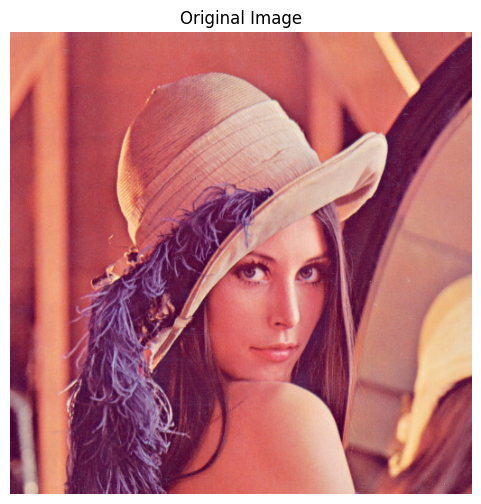

In [8]:
# Display the original image with matplotlib.
plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')
plt.show()

**Cell 2: Edge Detection using the Canny Algorithm**

**Description:** This Cell 2 converts the color image into grayscale, a necessary step for many image processing tasks. The Canny algorithm is then used to detect edges by identifying areas of rapid intensity change. The detected edges are visualized as a binary image, giving a clear view of the boundaries and transitions present in the image.

In [10]:
#python
# Convert the image to grayscale.
# - Edge detection algorithms, such as Canny, operate on single-channel grayscale images.
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)



In [11]:
# Apply the Canny edge detection algorithm.
# - The parameters threshold1 and threshold2 (100 and 200) control the sensitivity.
# - Lower thresholds capture more edges but may include noise; higher thresholds provide cleaner edges.
edges = cv2.Canny(gray, threshold1=100, threshold2=200)



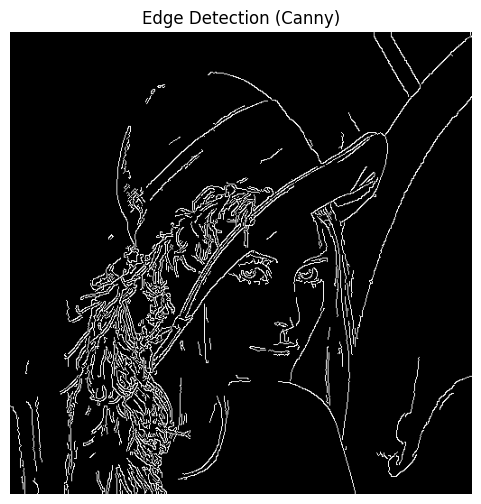

In [12]:
# Display the edge-detected image.
plt.figure(figsize=(6,6))
plt.imshow(edges, cmap='gray')
plt.title('Edge Detection (Canny)')
plt.axis('off')
plt.show()

**Cell 3: Plot a Histogram of Pixel Intensities**

**Description:** In this  3, the histogram of the grayscale image is computed using OpenCV’s calcHist function. The histogram provides a visual representation of the distribution of pixel intensities. You can use this information to assess contrast and determine if any enhancement or normalization is needed for further processing.

In [13]:
#python
# Compute the histogram of the grayscale image.
# - cv2.calcHist calculates the frequency of pixel intensities.
# - The histogram shows how many pixels have each intensity value from 0 to 255.
hist = cv2.calcHist([gray], channels=[0], mask=None, histSize=[256], ranges=[0,256])



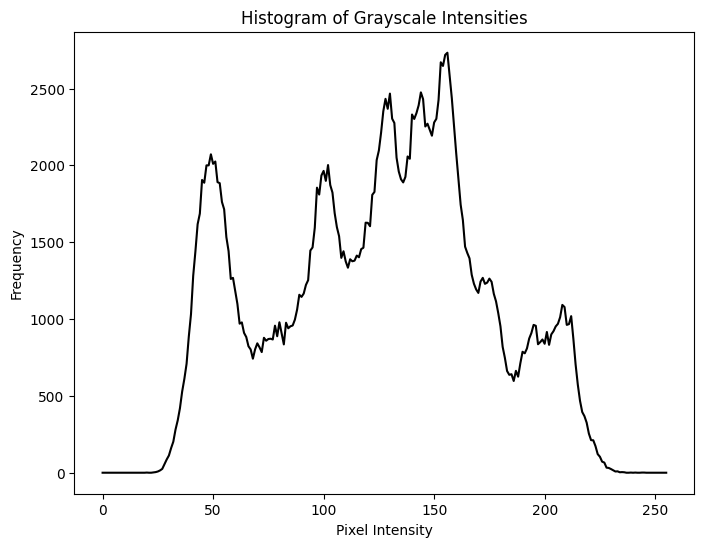

In [14]:
# Plot the histogram using matplotlib.
plt.figure(figsize=(8,6))
plt.plot(hist, color='black')
plt.title("Histogram of Grayscale Intensities")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

**Cell 4: Extract and Visualize Feature Maps Using a Simple CNN**

**Description:** This Cell 4 demonstrates how to build a simple Convolutional Neural Network (CNN) using TensorFlow/Keras. The image is preprocessed (normalized and reshaped) and passed through a CNN with one convolutional layer. The network extracts eight feature maps, each representing different learned aspects of the image. These feature maps are then displayed in a grid, showcasing how convolutional layers highlight important features.



In [16]:
#python
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D



In [17]:
# Preprocess the image for the CNN:
# - Convert the image pixels to float32 and normalize them to the range [0, 1].
# - Expand dimensions to add a batch dimension, as required by Keras models.
input_img = image_rgb.astype('float32') / 255.0
input_img = np.expand_dims(input_img, axis=0)  # Final shape: (1, height, width, 3)



In [18]:
# Build a simple CNN model with a single convolutional layer:
# - The input layer takes the shape of our preprocessed image.
# - The convolutional layer applies 8 filters with a 3x3 kernel, using ReLU activation.
# - Padding is set to "same" to ensure that the output feature maps have the same spatial dimensions as the input.
input_layer = Input(shape=input_img.shape[1:])  # Exclude the batch dimension.
conv_layer = Conv2D(filters=8, kernel_size=(3,3), activation='relu', padding='same')(input_layer)
model = Model(inputs=input_layer, outputs=conv_layer)



In [19]:
# Explanation:
# This simple CNN applies 8 different convolutional filters to the image, thereby generating 8 feature maps.
# These feature maps highlight various aspects, such as edges and textures, learned from the image.

# Pass the image through the CNN to obtain the feature maps.
feature_maps = model.predict(input_img)
# Remove the batch dimension for visualization. The resulting shape is (height, width, 8).
feature_maps = feature_maps[0]



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


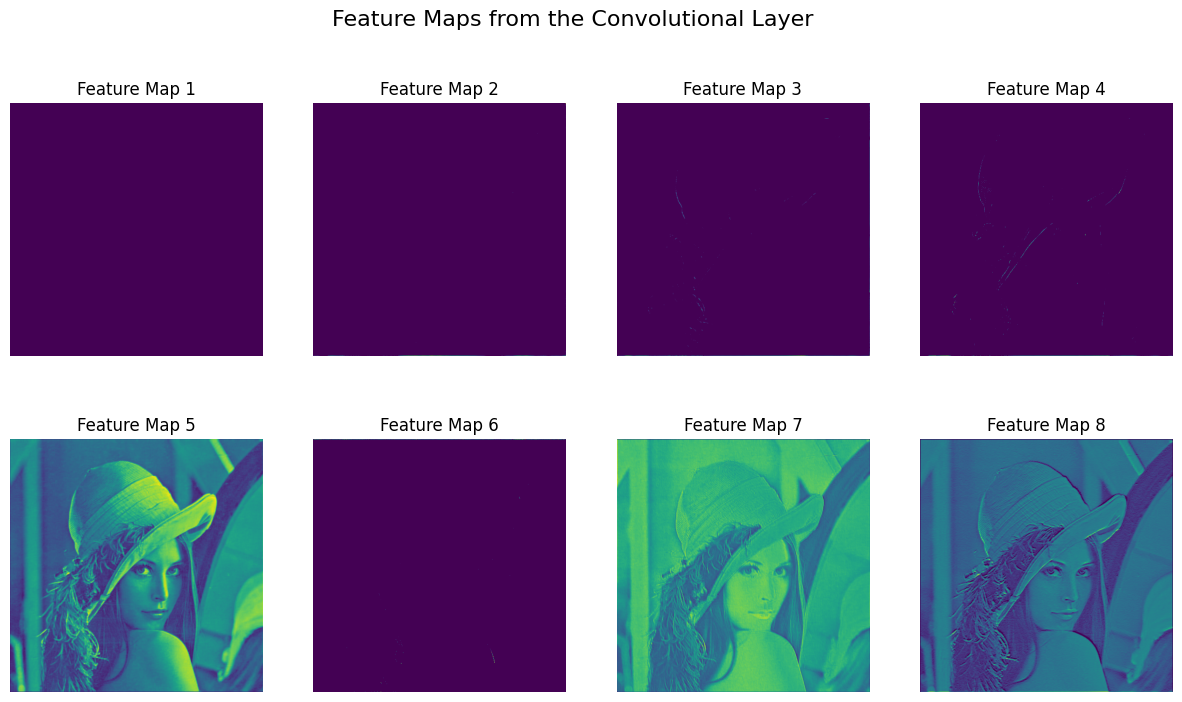

In [20]:
# Visualize each of the 8 feature maps.
# - The results are arranged in a grid format with two rows.
num_filters = feature_maps.shape[-1]
plt.figure(figsize=(15,8))
for i in range(num_filters):
    plt.subplot(2, num_filters // 2, i+1)
    plt.imshow(feature_maps[:,:,i], cmap='viridis')
    plt.title(f'Feature Map {i+1}')
    plt.axis('off')
plt.suptitle("Feature Maps from the Convolutional Layer", fontsize=16)
plt.show()

**By following this script,** you'll gain hands-on experience with fundamental computer vision techniques in Python. As you explore these concepts further, try adjusting parameters and experimenting with different images to see how the outputs change. Happy coding!